In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [2]:
! pip install --upgrade torch

## Reinforcement Learning Generative Adversarial Network by using Boosted models as discriminators

Generator class is a straightforward feedforward neural network. It takes a vector of 10 random numbers as an input and passes it through a series of linear layers, batch normalization, and LeakyReLU activations. The final layer uses a Sigmoid activation


The boosted models act as a judge and, since the error is not backpropagable, the generator learns through a reward mechanism like RL

Starting Training...
Epoch 0 | Loss: 0.2245 | Avg Reward: 0.3010


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 10 | Loss: 0.1043 | Avg Reward: 0.2523
Epoch 20 | Loss: 0.0466 | Avg Reward: 0.2437


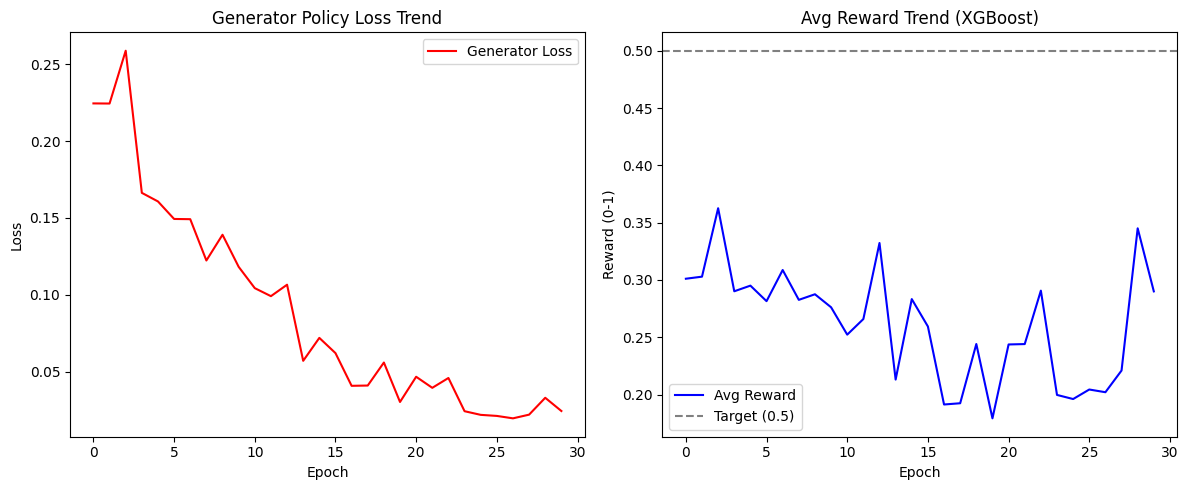

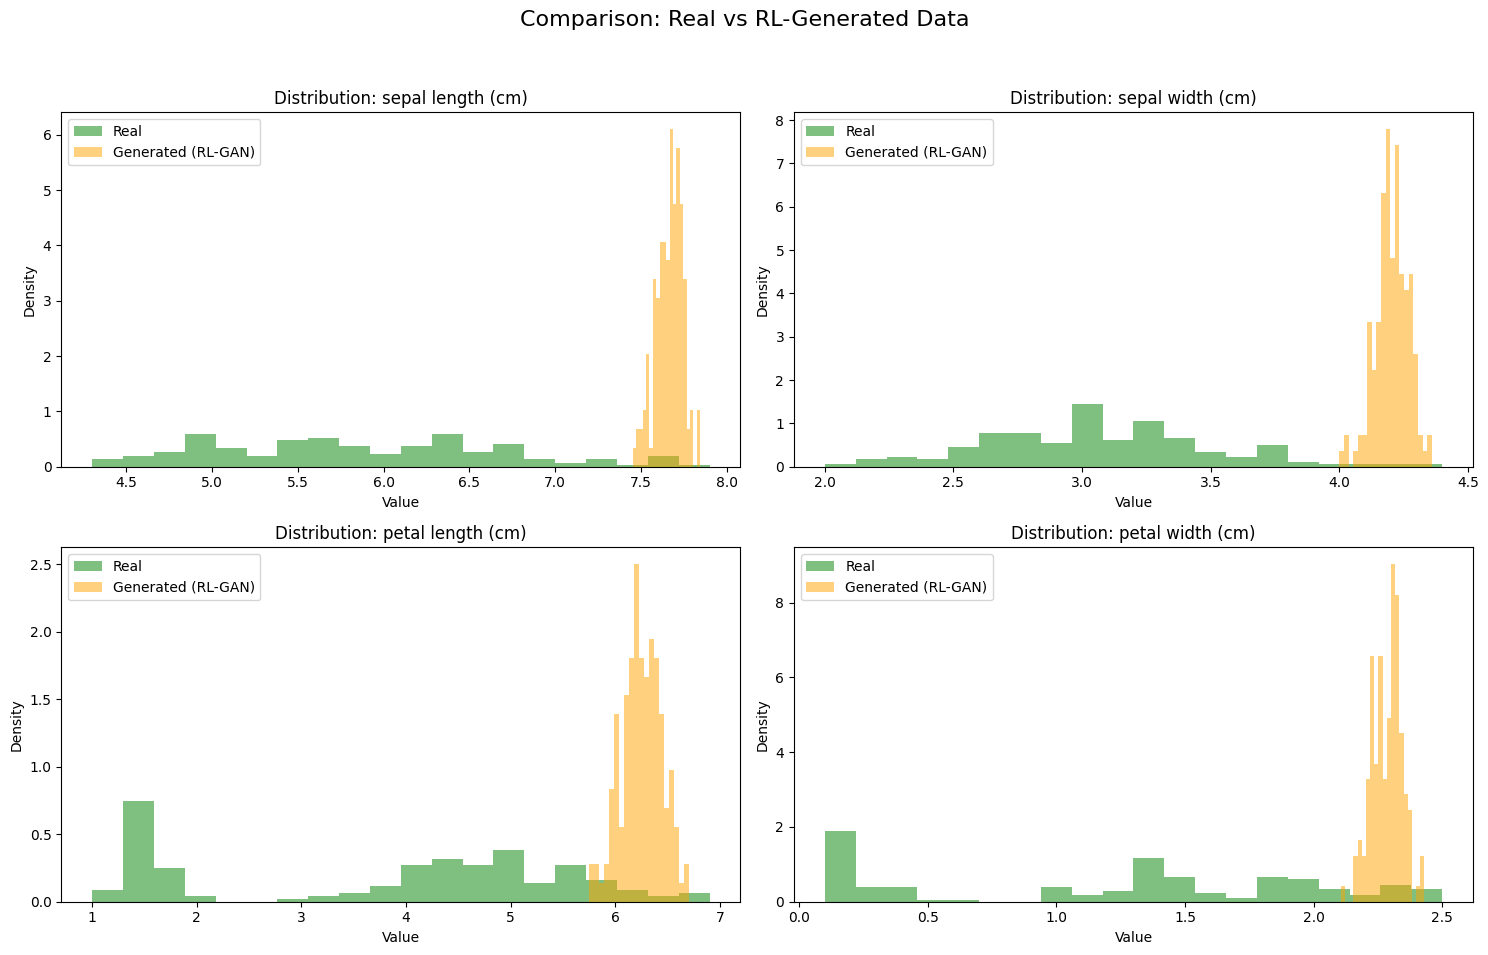

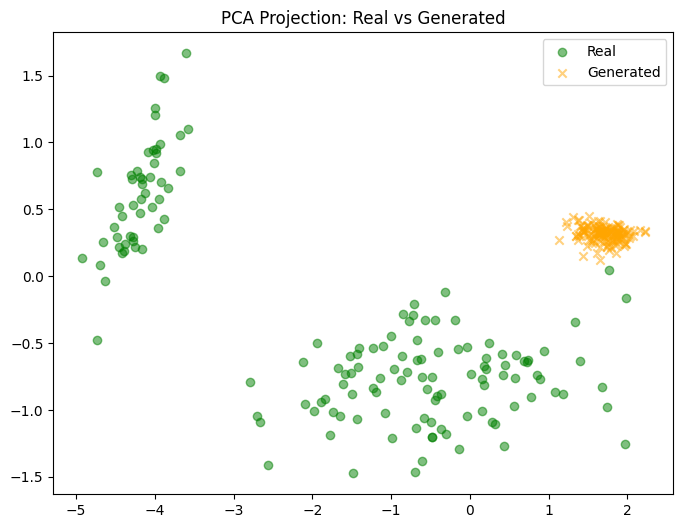

--- DATA SAMPLE COMPARISON (First 5 Real vs Generated) ---
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)    Source
          5.100000          3.500000           1.400000          0.200000      REAL
          4.900000          3.000000           1.400000          0.200000      REAL
          4.700000          3.200000           1.300000          0.200000      REAL
          4.600000          3.100000           1.500000          0.200000      REAL
          5.000000          3.600000           1.400000          0.200000      REAL
          7.744621          4.249965           6.407928          2.353453 GENERATED
          7.660559          4.193346           6.122828          2.284443 GENERATED
          7.642874          4.195749           6.206345          2.232177 GENERATED
          7.504548          4.114589           5.943286          2.209851 GENERATED
          7.762654          4.222593           6.276602          2.333141 GENERATED

--- QUICK STATIS

In [3]:
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data)
n_features = real_data.shape[1]

#  Generator Model
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            # Block 2
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            # Block 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            # Output Layer
            nn.Linear(64, output_dim),
            nn.Sigmoid() # Bounds output to [0, 1] to match the MinMaxScaler
        )

    def forward(self, z):
        return self.model(z)

def train_discriminator(gen_model, real_samples, n_noise):
    z = torch.randn(n_noise, 10)
    with torch.no_grad():
        fake_samples = gen_model(z).numpy()

    X = np.vstack([real_samples, fake_samples])
    y = np.hstack([np.ones(len(real_samples)), np.zeros(len(fake_samples))])

    # Weak discriminator to prevent overpowering the generator early on
    clf = xgb.XGBClassifier(n_estimators=5, max_depth=3, use_label_encoder=False, eval_metric='logloss')
    clf.fit(X, y)
    return clf

#  Training Parameters & Logging
latent_dim = 10
gen = Generator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.005)
epochs = 30
batch_size = 32

history = {
    'gen_loss': [],
    'avg_reward': []
}

print("Starting Training...")

for epoch in range(epochs):
    # Update Discriminator
    d_model = train_discriminator(gen, real_data, n_noise=batch_size)

    # Update Generator (RL Step)
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Get rewards from XGBoost
    rewards = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards, dtype=torch.float32)

    # Calculate policy loss: -Reward * log(prob)
    # Using mean log-probability of the output as a proxy for the policy
    log_probs = torch.log(fake_data + 1e-8).mean(dim=1)
    loss = -torch.mean(rewards * log_probs)

    loss.backward()
    optimizer.step()

    # Logging
    history['gen_loss'].append(loss.item())
    history['avg_reward'].append(rewards.mean().item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Avg Reward: {rewards.mean().item():.4f}")

# Plot Training Metrics
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history['gen_loss'], color='red', label='Generator Loss')
plt.title('Generator Policy Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Reward Plot
plt.subplot(1, 2, 2)
plt.plot(history['avg_reward'], color='blue', label='Avg Reward')
plt.title('Avg Reward Trend (XGBoost)')
plt.xlabel('Epoch')
plt.ylabel('Reward (0-1)')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Target (0.5)')
plt.legend()

plt.tight_layout()
plt.show()

#  Generate & Inverse Transform
# Generate a sample matching the real dataset size for a fair comparison
z_test = torch.randn(len(real_data), latent_dim)
gen.eval()
with torch.no_grad():
    fake_data_scaled = gen(z_test).numpy()

# Inverse transform to original scale
real_data_inv = scaler.inverse_transform(real_data)
fake_data_inv = scaler.inverse_transform(fake_data_scaled)

feature_names = iris.feature_names

# Plot Feature Distributions
plt.figure(figsize=(15, 10))
for i in range(n_features):
    plt.subplot(2, 2, i+1)

    # Real data histogram
    plt.hist(real_data_inv[:, i], bins=20, alpha=0.5, label='Real', color='green', density=True)

    # Generated data histogram
    plt.hist(fake_data_inv[:, i], bins=20, alpha=0.5, label='Generated (RL-GAN)', color='orange', density=True)

    plt.title(f'Distribution: {feature_names[i]}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()

plt.suptitle("Comparison: Real vs RL-Generated Data", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#  2D PCA Projection
pca = PCA(n_components=2)
all_data = np.vstack([real_data_inv, fake_data_inv])
pca_res = pca.fit_transform(all_data)

real_pca = pca_res[:len(real_data_inv)]
fake_pca = pca_res[len(real_data_inv):]

plt.figure(figsize=(8, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Real', c='green')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label='Generated', c='orange', marker='x')
plt.title("PCA Projection: Real vs Generated")
plt.legend()
plt.show()

# --- 8. Statistical Printouts ---
# 1. Create DataFrames
df_real = pd.DataFrame(real_data_inv, columns=feature_names)
df_generated = pd.DataFrame(fake_data_inv, columns=feature_names)

# 2. Add source labels
df_real['Source'] = 'REAL'
df_generated['Source'] = 'GENERATED'

# 3. Concatenate head samples for a quick look
sample_comparison = pd.concat([df_real.head(5), df_generated.head(5)])

print("--- DATA SAMPLE COMPARISON (First 5 Real vs Generated) ---")
print(sample_comparison.to_string(index=False))

# 4. Descriptive statistics comparison
print("\n--- QUICK STATISTICAL ANALYSIS ---")
stats_real = df_real.drop('Source', axis=1).describe().loc[['mean', 'std', 'min', 'max']]
stats_generated = df_generated.drop('Source', axis=1).describe().loc[['mean', 'std', 'min', 'max']]

print("\nREAL DATA STATS:")
print(stats_real.to_string())
print("\nGENERATED DATA STATS:")
print(stats_generated.to_string())

Improvements:

*   Improved NN structure, added dropout and explicit L2 weight decay in optim
*   added entropy factor to loss to try to mitigate mode collapse



Starting Training...
Epoch   0 | Loss: 0.5184 | Avg Reward: 0.7546 | Diff: 0.2546
Epoch  20 | Loss: 0.1968 | Avg Reward: 0.4058 | Diff: 0.0942
Epoch  40 | Loss: 0.1010 | Avg Reward: 0.2462 | Diff: 0.2538

--- EARLY STOPPING triggered at epoch 44 ---
Model reached maximum stability against the XGBoost discriminator.

--- DESCRIPTIVE STATISTICS COMPARISON ---

REAL DATA MEAN:
 sepal length (cm)    5.843335
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199334
dtype: float32

GENERATED DATA MEAN:
 sepal length (cm)    6.183907
sepal width (cm)     3.389919
petal length (cm)    4.279863
petal width (cm)     1.340735
dtype: float32


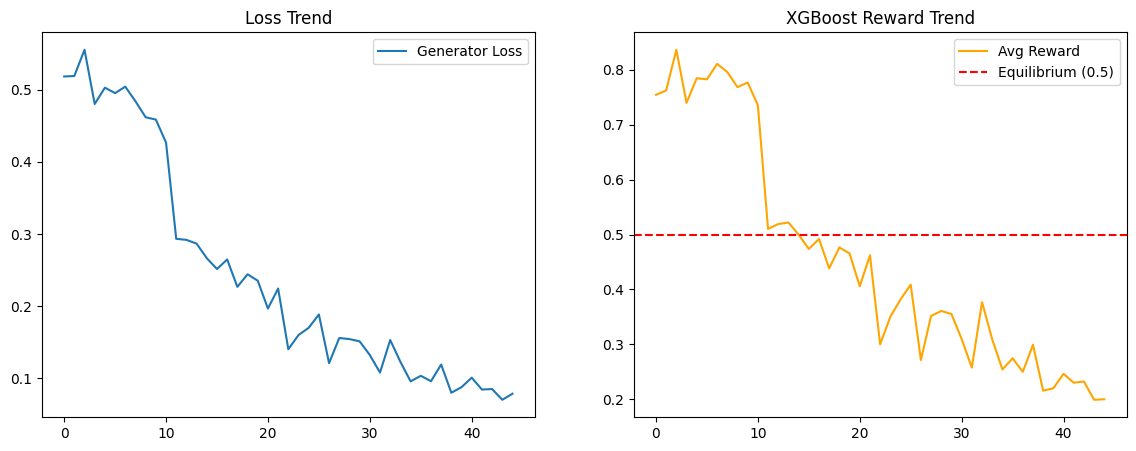


            STATISTICAL COMPARISON: REAL VS GENERATED DATA
                   Mean Real  Mean Generated  Std Real  Std Generated  Min Real  Min Generated  Max Real  Max Generated
sepal length (cm)   5.843333        6.183908  0.828066       0.065510       4.3       6.043880       7.9       6.380334
sepal width (cm)    3.057333        3.389918  0.435866       0.043133       2.0       3.281631       4.4       3.510216
petal length (cm)   3.758000        4.279863  1.765299       0.097485       1.0       4.007711       6.9       4.545897
petal width (cm)    1.199333        1.340735  0.762238       0.047011       0.1       1.131225       2.5       1.445564

Mean Absolute Error (MAE) of feature means: 0.3341
>>> Warning: Significant discrepancy remains between distributions.


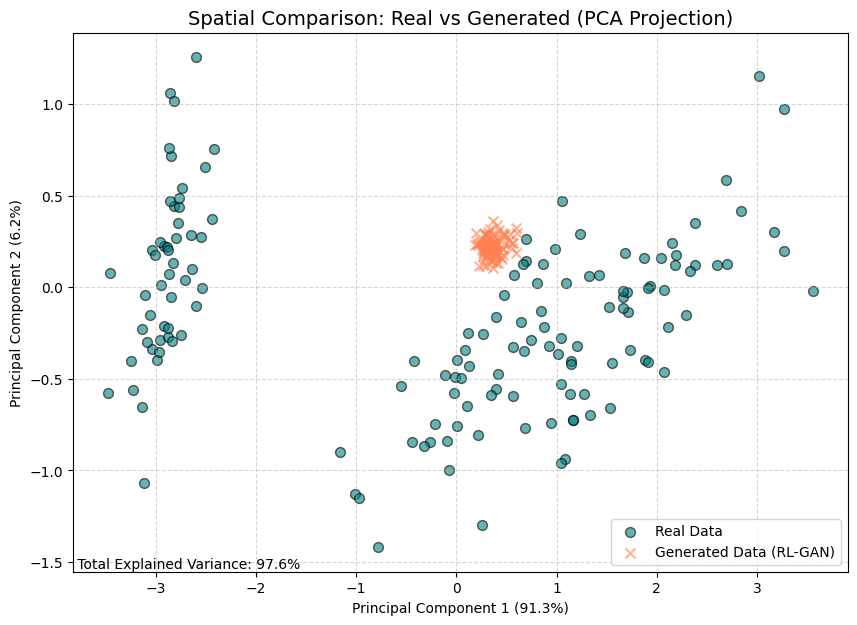

In [ ]:
# Data Setup
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data).astype(np.float32)
n_features = real_data.shape[1]

# --- 2. Robust Generator (BN, Dropout, Sequential blocks) ---
class RobustGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(RobustGenerator, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2)
        )

        self.output = nn.Sequential(
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.layer1(z)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.output(x)

# XGBoost Discriminator (with Label Smoothing)
def train_xgb_discriminator(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])

    # Label Smoothing: Use 0.9 for real samples so XGBoost doesn't become overly confident
    y = np.hstack([np.full(len(real_samples), 1.0), np.zeros(len(fake_samples))])

    model = xgb.XGBClassifier(n_estimators=15, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X, y)
    return model

#  Training Loop with Early Stopping
latent_dim = 20
batch_size = 64
gen = RobustGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0005, weight_decay=1e-5) # L2 regularization

epochs = 500
patience = 30
best_reward_diff = float('inf') # Track closest distance to 0.5 (equilibrium)
counter = 0
history = {'loss': [], 'reward': []}

print("Starting Training...")

for epoch in range(epochs):
    # A. Train Discriminator
    d_model = train_xgb_discriminator(gen, real_data, latent_dim, batch_size)

    # B. Train Generator
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Get raw rewards from XGBoost
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # Calculate policy loss with Entropy Bonus to avoid Mode Collapse
    log_probs = torch.log(fake_data + 1e-8)
    entropy_bonus = fake_data.var(dim=0).mean() # Encourage batch variance
    loss = -torch.mean(rewards * log_probs) - (0.05 * entropy_bonus)

    loss.backward()
    optimizer.step()

    # Early stopping and logging logic
    avg_reward = rewards.mean().item()
    history['loss'].append(loss.item())
    history['reward'].append(avg_reward)

    # Halt if the reward stabilizes around 0.5
    reward_diff = abs(avg_reward - 0.5)
    if reward_diff < best_reward_diff:
        best_reward_diff = reward_diff
        counter = 0
        torch.save(gen.state_dict(), 'best_gen.pth')
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Avg Reward: {avg_reward:.4f} | Diff: {reward_diff:.4f}")

    if counter >= patience:
        print(f"\n--- EARLY STOPPING triggered at epoch {epoch} ---")
        print("Model reached maximum stability against the XGBoost discriminator.")
        break

# Load the best weights before final evaluation
gen.load_state_dict(torch.load('best_gen.pth', weights_only=True))

# --- 5. Final Evaluation & Visualization ---
gen.eval()
with torch.no_grad():
    fake_final = gen(torch.randn(100, latent_dim)).numpy()
    fake_final = scaler.inverse_transform(fake_final)

real_final = scaler.inverse_transform(real_data)

# Create DataFrames for quick comparison
df_fake = pd.DataFrame(fake_final, columns=iris.feature_names)
df_real = pd.DataFrame(real_final, columns=iris.feature_names)

print("\n--- DESCRIPTIVE STATISTICS COMPARISON ---")
print("\nREAL DATA MEAN:\n", df_real.mean())
print("\nGENERATED DATA MEAN:\n", df_fake.mean())

# Plot training metrics
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Generator Loss')
plt.title('Loss Trend')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], color='orange', label='Avg Reward')
plt.axhline(y=0.5, color='red', linestyle='--', label='Equilibrium (0.5)')
plt.title('XGBoost Reward Trend')
plt.legend()
plt.show()

# --- DETAILED STATISTICAL ANALYSIS ---

stats_real = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_generated = df_fake.describe().loc[['mean', 'std', 'min', 'max']]

# Merge dataframes for direct side-by-side metric comparison
comparison_final = pd.DataFrame(index=df_real.columns)

for metric in ['mean', 'std', 'min', 'max']:
    comparison_final[f'{metric.capitalize()} Real'] = stats_real.loc[metric]
    comparison_final[f'{metric.capitalize()} Generated'] = stats_generated.loc[metric]

print("\n" + "="*80)
print("            STATISTICAL COMPARISON: REAL VS GENERATED DATA")
print("="*80)
print(comparison_final.to_string())
print("="*80)

# Mean Absolute Error (MAE) between feature means
mean_error = np.abs(df_real.mean() - df_fake.mean()).mean()
print(f"\nMean Absolute Error (MAE) of feature means: {mean_error:.4f}")

if mean_error < 0.1:
    print(">>> Excellent: Generator closely replicates real means.")
elif mean_error < 0.3:
    print(">>> Good: Distributions are close, but could be refined.")
else:
    print(">>> Warning: Significant discrepancy remains between distributions.")

# --- 2D VISUALIZATION (PCA) ---

#  Prepare combined data for PCA projection
X_combined = np.vstack([df_real.values, df_fake.values])

#  Reduce to 2 principal components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_combined)

#  Split results back out
pca_real = pca_result[:len(df_real)]
pca_fake = pca_result[len(df_real):]

# 4. Plot
plt.figure(figsize=(10, 7))

plt.scatter(pca_real[:, 0], pca_real[:, 1],
            color='teal', alpha=0.6, label='Real Data',
            edgecolors='k', s=50)

plt.scatter(pca_fake[:, 0], pca_fake[:, 1],
            color='coral', alpha=0.6, label='Generated Data (RL-GAN)',
            marker='x', s=50)

var_exp = pca.explained_variance_ratio_ * 100

plt.title('Spatial Comparison: Real vs Generated (PCA Projection)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Add variance annotation
plt.text(plt.xlim()[0], plt.ylim()[0],
         f" Total Explained Variance: {sum(var_exp):.1f}%",
         fontsize=10, verticalalignment='bottom')

plt.show()

improvement:

*   just added a term to tune the entropy relevance



Starting Training...
Epoch   0 | Loss: 0.5840 | Avg Reward: 0.8378 | Diff: 0.3378
Epoch  20 | Loss: 0.1911 | Avg Reward: 0.3999 | Diff: 0.1001
Epoch  40 | Loss: 0.0986 | Avg Reward: 0.2406 | Diff: 0.2594

--- EARLY STOPPING triggered at epoch 56 ---
Model reached maximum stability against the XGBoost discriminator.

--- DESCRIPTIVE STATISTICS COMPARISON ---

REAL DATA MEAN:
 sepal length (cm)    5.843335
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199334
dtype: float32

GENERATED DATA MEAN:
 sepal length (cm)    6.261049
sepal width (cm)     3.465236
petal length (cm)    4.623940
petal width (cm)     1.430533
dtype: float32


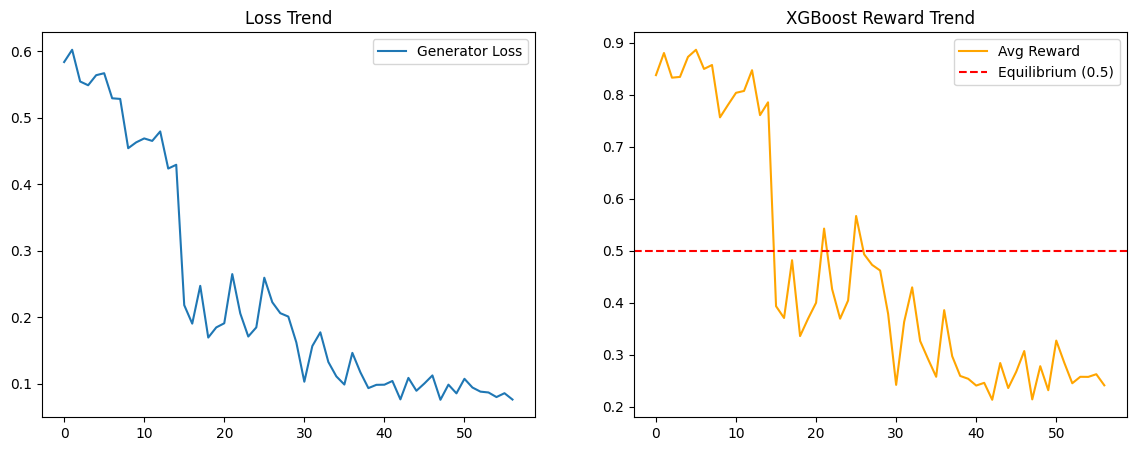


            STATISTICAL COMPARISON: REAL VS GENERATED DATA
                   Mean Real  Mean Generated  Std Real  Std Generated  Min Real  Min Generated  Max Real  Max Generated
sepal length (cm)   5.843333        6.261050  0.828066       0.184761       4.3       5.892016       7.9       6.785272
sepal width (cm)    3.057333        3.465236  0.435866       0.098349       2.0       3.227395       4.4       3.812434
petal length (cm)   3.758000        4.623940  1.765299       0.247096       1.0       3.899340       6.9       5.450892
petal width (cm)    1.199333        1.430533  0.762238       0.126139       0.1       1.179668       2.5       1.791908

Mean Absolute Error (MAE) of feature means: 0.4807
>>> Warning: Significant discrepancy remains between distributions.


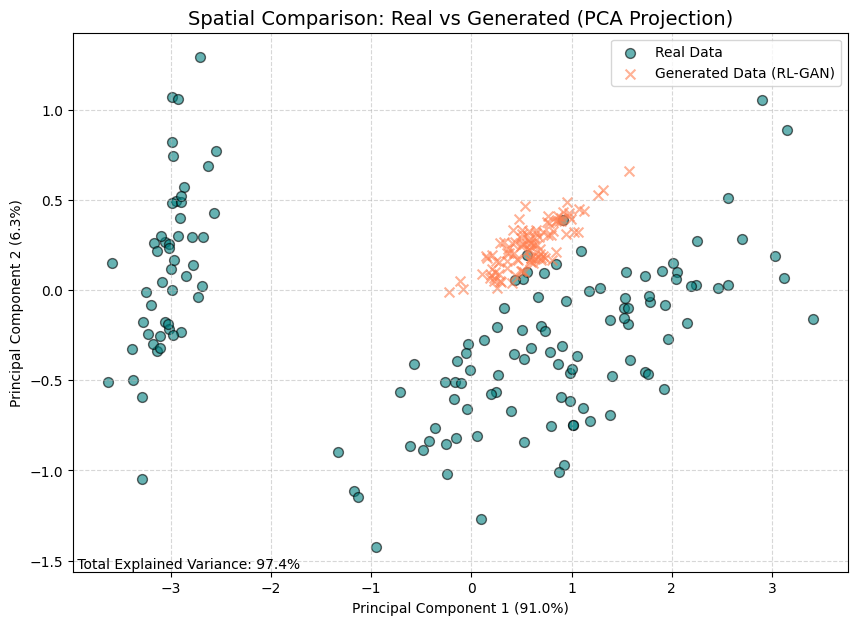

In [ ]:
# Data Setup
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data).astype(np.float32)
n_features = real_data.shape[1]

# Robust Generator (BN, Dropout, Sequential blocks)
class RobustGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(RobustGenerator, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2)
        )

        self.output = nn.Sequential(
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.layer1(z)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.output(x)

# XGBoost Discriminator (with Label Smoothing)
def train_xgb_discriminator(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])

    # Label Smoothing: Use 0.9 for real samples so XGBoost doesn't become overly confident
    y = np.hstack([np.full(len(real_samples), 1.0), np.zeros(len(fake_samples))])

    model = xgb.XGBClassifier(n_estimators=15, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X, y)
    return model

# Training Loop with Early Stopping
latent_dim = 20
batch_size = 64
gen = RobustGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0005, weight_decay=1e-5) # L2 regularization via weight decay

epochs = 500
patience = 30
best_reward_diff = float('inf') # Track closest distance to 0.5 (equilibrium)
counter = 0
history = {'loss': [], 'reward': []}

print("Starting Training...")

for epoch in range(epochs):
    # A. Train Discriminator
    d_model = train_xgb_discriminator(gen, real_data, latent_dim, batch_size)

    # B. Train Generator
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Get raw rewards from XGBoost
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # Calculate feature-wise variance across the current batch
    batch_variance_per_feature = fake_data.var(dim=0)

    # The mean of all feature variances serves as our diversity metric
    entropy_bonus = batch_variance_per_feature.mean()

    # Beta determines the weight of the entropy bonus (increase if mode collapse occurs)
    beta = 0.1

    # Standard policy loss minus entropy bonus (optimizer minimizes, so we subtract to maximize entropy)
    log_probs = torch.log(fake_data + 1e-8)
    loss = -torch.mean(rewards * log_probs) - (beta * entropy_bonus)

    loss.backward()
    optimizer.step()

    # Early stopping and logging logic
    avg_reward = rewards.mean().item()
    history['loss'].append(loss.item())
    history['reward'].append(avg_reward)

    # Halt if the reward stabilizes around 0.5
    reward_diff = abs(avg_reward - 0.5)
    if reward_diff < best_reward_diff:
        best_reward_diff = reward_diff
        counter = 0
        torch.save(gen.state_dict(), 'best_gen.pth')
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Avg Reward: {avg_reward:.4f} | Diff: {reward_diff:.4f}")

    if counter >= patience:
        print(f"\n--- EARLY STOPPING triggered at epoch {epoch} ---")
        print("Model reached maximum stability against the XGBoost discriminator.")
        break

# Load the best weights before final evaluation
gen.load_state_dict(torch.load('best_gen.pth', weights_only=True))

# --- 5. Final Evaluation & Visualization ---
gen.eval()
with torch.no_grad():
    fake_final = gen(torch.randn(100, latent_dim)).numpy()
    fake_final = scaler.inverse_transform(fake_final)

real_final = scaler.inverse_transform(real_data)

# Create DataFrames for quick comparison
df_fake = pd.DataFrame(fake_final, columns=iris.feature_names)
df_real = pd.DataFrame(real_final, columns=iris.feature_names)

print("\n--- DESCRIPTIVE STATISTICS COMPARISON ---")
print("\nREAL DATA MEAN:\n", df_real.mean())
print("\nGENERATED DATA MEAN:\n", df_fake.mean())

# Plot training metrics
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Generator Loss')
plt.title('Loss Trend')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], color='orange', label='Avg Reward')
plt.axhline(y=0.5, color='red', linestyle='--', label='Equilibrium (0.5)')
plt.title('XGBoost Reward Trend')
plt.legend()
plt.show()

# --- DETAILED STATISTICAL ANALYSIS ---

stats_real = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_generated = df_fake.describe().loc[['mean', 'std', 'min', 'max']]

# Merge dataframes for direct side-by-side metric comparison
comparison_final = pd.DataFrame(index=df_real.columns)

for metric in ['mean', 'std', 'min', 'max']:
    comparison_final[f'{metric.capitalize()} Real'] = stats_real.loc[metric]
    comparison_final[f'{metric.capitalize()} Generated'] = stats_generated.loc[metric]

print("\n" + "="*80)
print("            STATISTICAL COMPARISON: REAL VS GENERATED DATA")
print("="*80)
print(comparison_final.to_string())
print("="*80)

# Mean Absolute Error (MAE) between feature means
mean_error = np.abs(df_real.mean() - df_fake.mean()).mean()
print(f"\nMean Absolute Error (MAE) of feature means: {mean_error:.4f}")

if mean_error < 0.1:
    print(">>> Excellent: Generator closely replicates real means.")
elif mean_error < 0.3:
    print(">>> Good: Distributions are close, but could be refined.")
else:
    print(">>> Warning: Significant discrepancy remains between distributions.")

# --- 2D VISUALIZATION (PCA) ---

# Prepare combined data for PCA projection
X_combined = np.vstack([df_real.values, df_fake.values])

#  Reduce to 2 principal components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_combined)

# Split results back out
pca_real = pca_result[:len(df_real)]
pca_fake = pca_result[len(df_real):]

# 4. Plot
plt.figure(figsize=(10, 7))

plt.scatter(pca_real[:, 0], pca_real[:, 1],
            color='teal', alpha=0.6, label='Real Data',
            edgecolors='k', s=50)

plt.scatter(pca_fake[:, 0], pca_fake[:, 1],
            color='coral', alpha=0.6, label='Generated Data (RL-GAN)',
            marker='x', s=50)

var_exp = pca.explained_variance_ratio_ * 100

plt.title('Spatial Comparison: Real vs Generated (PCA Projection)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Add variance annotation
plt.text(plt.xlim()[0], plt.ylim()[0],
         f" Total Explained Variance: {sum(var_exp):.1f}%",
         fontsize=10, verticalalignment='bottom')

plt.show()

Improvements:

*   Added noise in the training to prevent mode collapse
*   slightly changed network structure



Starting training...
Epoch   0 | Loss: 0.3696 | Avg Reward: 0.6007 | Diff: 0.1007
Epoch  20 | Loss: 0.1901 | Avg Reward: 0.4508 | Diff: 0.0492
Epoch  40 | Loss: 0.0594 | Avg Reward: 0.3350 | Diff: 0.1650

--- EARLY STOPPING triggered at epoch 52 ---
Model reached equilibrium with the XGBoost discriminator.

--- DESCRIPTIVE STATISTICS COMPARISON ---

REAL DATA MEAN:
 sepal length (cm)    5.843335
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199334
dtype: float32

GENERATED DATA MEAN:
 sepal length (cm)    6.449296
sepal width (cm)     3.316239
petal length (cm)    4.358083
petal width (cm)     1.421090
dtype: float32


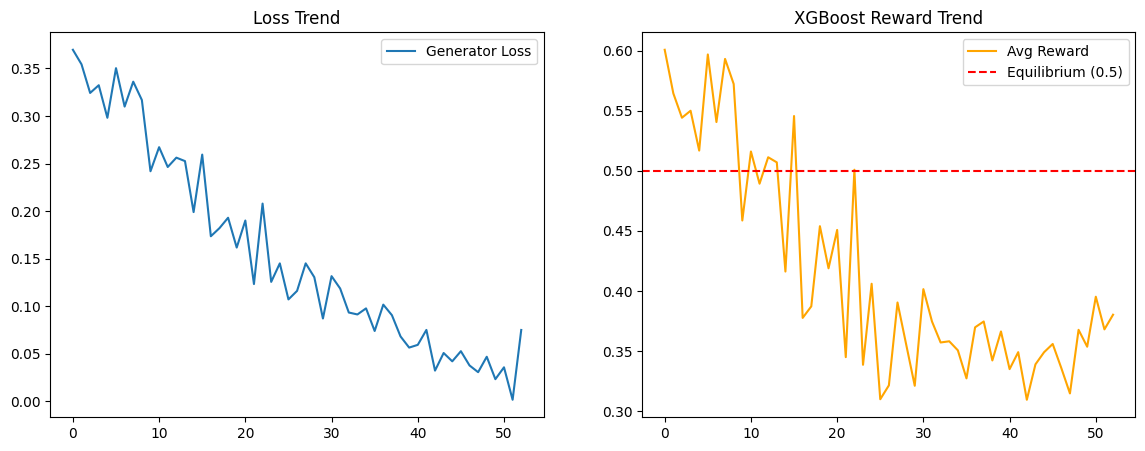


            STATISTICAL COMPARISON: REAL VS GENERATED DATA
                   Mean Real  Mean Generated  Std Real  Std Generated  Min Real  Min Generated  Max Real  Max Generated
sepal length (cm)   5.843333        6.449296  0.828066       0.242492       4.3       5.842849       7.9       7.042169
sepal width (cm)    3.057333        3.316239  0.435866       0.170689       2.0       2.935090       4.4       3.809422
petal length (cm)   3.758000        4.358083  1.765299       0.576240       1.0       2.380779       6.9       5.756988
petal width (cm)    1.199333        1.421090  0.762238       0.223624       0.1       0.769835       2.5       1.887686

Mean Absolute Error (MAE) of feature means: 0.4217
>>> Warning: Significant discrepancy remains between distributions.


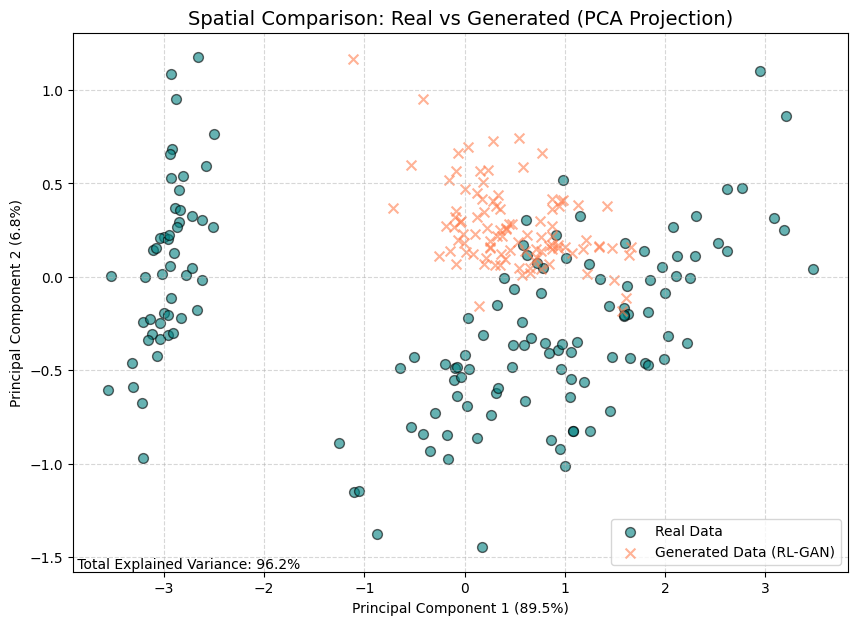

In [4]:
# Data Setup
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data).astype(np.float32)
n_features = real_data.shape[1]

# Robust Generator (BN, Dropout, Residual-like)
class VariedGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(VariedGenerator, self).__init__()

        # Layer 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)

        # Layer 2
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        # Output
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, z):
        # Layer 1
        x = torch.relu(self.bn1(self.fc1(z)))
        x = self.drop1(x)

        # Inject intermediate Gaussian noise proportional to activation intensity
        # Only applied during training to force structural variance
        if self.training:
            noise = torch.randn_like(x) * 0.1
            x = x + noise

        # Layer 2
        x = torch.relu(self.bn2(self.fc2(x)))

        # Output
        return torch.sigmoid(self.fc3(x))

#  XGBoost Discriminator (Label Smoothing)
def train_xgb_discriminator(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])

    y = np.hstack([np.full(len(real_samples), 1.0), np.zeros(len(fake_samples))])

    model = xgb.XGBClassifier(n_estimators=15, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X, y)
    return model

# Training Loop with Early Stopping
latent_dim = 20
batch_size = 64
gen = VariedGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0005, weight_decay=1e-5) # L2 regularization

epochs = 500
patience = 30
best_reward_diff = float('inf') # Track the closest reward to the 0.5 equilibrium
counter = 0
history = {'loss': [], 'reward': []}

print("Starting training...")

for epoch in range(epochs):
    # A. Train Discriminator
    d_model = train_xgb_discriminator(gen, real_data, latent_dim, batch_size)

    # B. Train Generator
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Get raw rewards from XGBoost
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # Calculate feature-wise variance across the batch
    batch_variance_per_feature = fake_data.var(dim=0)

    # Mean of variances acts as our diversity metric. We want to maximize this.
    entropy_bonus = batch_variance_per_feature.mean()

    # Entropy penalty weight. Scale up if mode collapse persists.
    beta = 5

    # Standard policy loss minus entropy bonus (optimizer minimizes, so we subtract to maximize entropy)
    log_probs = torch.log(fake_data + 1e-8)
    loss = -torch.mean(rewards * log_probs) - (beta * entropy_bonus)

    loss.backward()
    optimizer.step()

    # Early stopping and logging logic
    avg_reward = rewards.mean().item()
    history['loss'].append(loss.item())
    history['reward'].append(avg_reward)

    # Halt if reward stabilizes near 0.5
    reward_diff = abs(avg_reward - 0.5)
    if reward_diff < best_reward_diff:
        best_reward_diff = reward_diff
        counter = 0
        torch.save(gen.state_dict(), 'best_gen.pth')
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Avg Reward: {avg_reward:.4f} | Diff: {reward_diff:.4f}")

    if counter >= patience:
        print(f"\n--- EARLY STOPPING triggered at epoch {epoch} ---")
        print("Model reached equilibrium with the XGBoost discriminator.")
        break

# Load the best weights before evaluation
gen.load_state_dict(torch.load('best_gen.pth', weights_only=True))

#  Final Evaluation & Visualization
gen.eval()
with torch.no_grad():
    fake_final = gen(torch.randn(100, latent_dim)).numpy()
    fake_final = scaler.inverse_transform(fake_final)

real_final = scaler.inverse_transform(real_data)

# Create DataFrames for quick comparisons
df_fake = pd.DataFrame(fake_final, columns=iris.feature_names)
df_real = pd.DataFrame(real_final, columns=iris.feature_names)

print("\n--- DESCRIPTIVE STATISTICS COMPARISON ---")
print("\nREAL DATA MEAN:\n", df_real.mean())
print("\nGENERATED DATA MEAN:\n", df_fake.mean())

# Plot training metrics
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Generator Loss')
plt.title('Loss Trend')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], color='orange', label='Avg Reward')
plt.axhline(y=0.5, color='red', linestyle='--', label='Equilibrium (0.5)')
plt.title('XGBoost Reward Trend')
plt.legend()
plt.show()

# --- DETAILED STATISTICAL ANALYSIS ---

stats_real = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_generated = df_fake.describe().loc[['mean', 'std', 'min', 'max']]

# Merge dataframes for side-by-side metric comparison
comparison_final = pd.DataFrame(index=df_real.columns)

for metric in ['mean', 'std', 'min', 'max']:
    comparison_final[f'{metric.capitalize()} Real'] = stats_real.loc[metric]
    comparison_final[f'{metric.capitalize()} Generated'] = stats_generated.loc[metric]

print("\n" + "="*80)
print("            STATISTICAL COMPARISON: REAL VS GENERATED DATA")
print("="*80)
print(comparison_final.to_string())
print("="*80)

# Mean Absolute Error (MAE) between feature means
mean_error = np.abs(df_real.mean() - df_fake.mean()).mean()
print(f"\nMean Absolute Error (MAE) of feature means: {mean_error:.4f}")

if mean_error < 0.1:
    print(">>> Excellent: Generator closely replicates real means.")
elif mean_error < 0.3:
    print(">>> Good: Distributions are close, but could be refined.")
else:
    print(">>> Warning: Significant discrepancy remains between distributions.")

# --- 2D VISUALIZATION (PCA) ---

#  Prepare data for PCA projection
X_combined = np.vstack([df_real.values, df_fake.values])

#  Reduce to 2 principal components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_combined)

#  Split back into real and generated
pca_real = pca_result[:len(df_real)]
pca_fake = pca_result[len(df_real):]

#  Plot
plt.figure(figsize=(10, 7))

plt.scatter(pca_real[:, 0], pca_real[:, 1],
            color='teal', alpha=0.6, label='Real Data',
            edgecolors='k', s=50)

plt.scatter(pca_fake[:, 0], pca_fake[:, 1],
            color='coral', alpha=0.6, label='Generated Data (RL-GAN)',
            marker='x', s=50)

var_exp = pca.explained_variance_ratio_ * 100

plt.title('Spatial Comparison: Real vs Generated (PCA Projection)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Add explained variance annotation
plt.text(plt.xlim()[0], plt.ylim()[0],
         f" Total Explained Variance: {sum(var_exp):.1f}%",
         fontsize=10, verticalalignment='bottom')

plt.show()


Improvements:
*   Moment matching loss
*   Z-score scaling

*   Noise injection
*   weak critic






Starting training...
Epoch   0 | Avg Reward: 0.699 | Moment Loss: 0.0522
Epoch  50 | Avg Reward: 0.691 | Moment Loss: 0.0021
Epoch 100 | Avg Reward: 0.654 | Moment Loss: 0.0307
Epoch 150 | Avg Reward: 0.648 | Moment Loss: 0.0364
Epoch 200 | Avg Reward: 0.633 | Moment Loss: 0.0470
Epoch 250 | Avg Reward: 0.645 | Moment Loss: 0.0327

============================== STATISTICS ==============================
                sepal length (cm)  sepal width (cm)  petal length (cm)  \
REAL      mean           5.843333          3.057333           3.758000   
          std            0.828066          0.435866           1.765299   
          min            4.300000          2.000000           1.000000   
          max            7.900000          4.400000           6.900000   
GENERATED mean           5.316913          2.622023           3.567745   
          std            1.171876          0.694578           2.869631   
          min            4.300000          2.000000           1.000000   
 

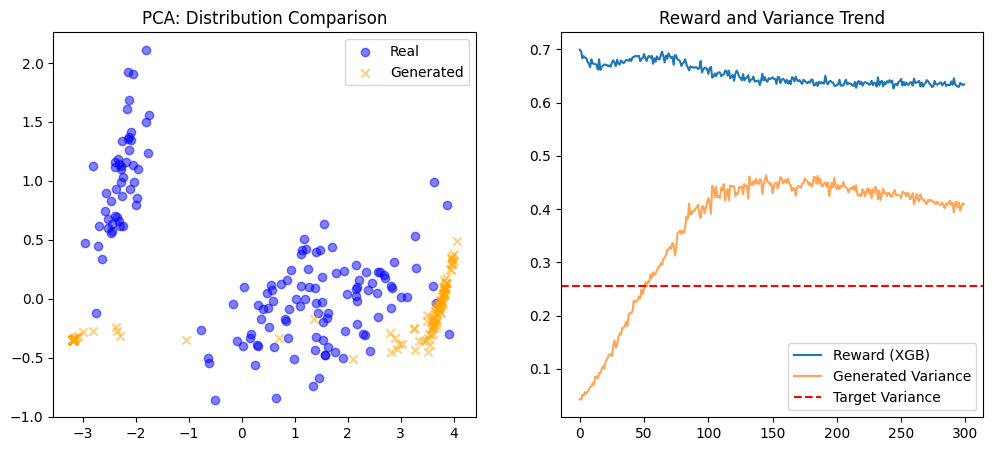

In [ ]:
# Data Setup
iris = load_iris()
scaler = MinMaxScaler()
real_data_raw = iris.data.astype(np.float32)
real_data_scaled = scaler.fit_transform(real_data_raw)
n_features = real_data_scaled.shape[1]
feature_names = iris.feature_names

# Target stats for the generator
target_mean = torch.tensor(real_data_scaled.mean(axis=0))
target_std = torch.tensor(real_data_scaled.std(axis=0))

# Generator
class UltimateGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(UltimateGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        # Inject noise during training to increase variance
        if self.training:
            z = z + torch.randn_like(z) * 0.1
        return self.net(z)

# Discriminator (Weak XGBoost)
def train_weak_xgb(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    y = np.hstack([np.ones(len(real_samples)), np.zeros(len(fake_samples))])

    # Keep it weak (shallow, few trees) so it doesn't overpower the generator
    model = xgb.XGBClassifier(
        n_estimators=3,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        eval_metric='logloss'
    )
    model.fit(X, y)
    return model

# Training Loop
latent_dim = 24
batch_size = 64
gen = UltimateGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0003)

epochs = 300
history = {'loss': [], 'reward': [], 'diversity': []}

print("Starting training...")

for epoch in range(epochs):
    # A. Train Discriminator
    d_model = train_weak_xgb(gen, real_data_scaled, latent_dim, batch_size)

    # B. Train Generator
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # 1. Raw XGBoost reward
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # 2. Reward Normalization (Z-score)
    # Forces the generator to keep improving even if rewards are high
    if rewards.std() > 1e-4:
        norm_rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
    else:
        norm_rewards = rewards - 0.5 # Offset if all rewards are identical

    # 3. Moment Matching Loss
    fake_mean = fake_data.mean(dim=0)
    fake_std = fake_data.std(dim=0)

    # Penalize deviations from target mean and std
    moment_loss = torch.mean((fake_mean - target_mean)**2) + torch.mean((fake_std - target_std)**2)

    # 4. Policy Gradient Loss
    log_probs = torch.log(fake_data + 1e-8)

    # Combine losses (moment matching heavily weighted to force distribution alignment)
    policy_loss = -torch.mean(norm_rewards * log_probs)
    total_loss = policy_loss + (10.0 * moment_loss)

    total_loss.backward()
    optimizer.step()

    # Logging
    history['loss'].append(total_loss.item())
    history['reward'].append(rewards.mean().item())
    history['diversity'].append(fake_std.mean().item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Avg Reward: {rewards.mean().item():.3f} | Moment Loss: {moment_loss.item():.4f}")

# Evaluation
gen.eval()
with torch.no_grad():
    final_z = torch.randn(200, latent_dim)
    fake_final_scaled = gen(final_z).numpy()
    fake_final = scaler.inverse_transform(fake_final_scaled)

df_real = pd.DataFrame(real_data_raw, columns=feature_names)
df_fake = pd.DataFrame(fake_final, columns=feature_names)

# Stats table
stats_real = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_fake = df_fake.describe().loc[['mean', 'std', 'min', 'max']]
comparison = pd.concat([stats_real, stats_fake], axis=0, keys=['REAL', 'GENERATED'])

print("\n" + "="*30 + " STATISTICS " + "="*30)
print(comparison)

# PCA Plot
pca = PCA(n_components=2)
all_pca = pca.fit_transform(np.vstack([real_data_raw, fake_final]))
real_pca = all_pca[:len(real_data_raw)]
fake_pca = all_pca[len(real_data_raw):]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Real', c='blue')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label='Generated', c='orange', marker='x')
plt.title("PCA: Distribution Comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], label='Reward (XGB)')
plt.plot(history['diversity'], label='Generated Variance', alpha=0.7)
plt.axhline(y=target_std.mean().item(), color='red', linestyle='--', label='Target Variance')
plt.title("Reward and Variance Trend")
plt.legend()
plt.show()

Improvements

*   Repelling loss
*   3 compoment losss



Starting training...
Epoch   0 | Avg Reward: 0.698 | Moment Loss: 0.0501
Epoch  50 | Avg Reward: 0.679 | Moment Loss: 0.0063
Epoch 100 | Avg Reward: 0.683 | Moment Loss: 0.0019
Epoch 150 | Avg Reward: 0.696 | Moment Loss: 0.0046
Epoch 200 | Avg Reward: 0.672 | Moment Loss: 0.0178
Epoch 250 | Avg Reward: 0.646 | Moment Loss: 0.0337

============================== STATISTICS ==============================
                sepal length (cm)  sepal width (cm)  petal length (cm)  \
REAL      mean           5.843333          3.057333           3.758000   
          std            0.828066          0.435866           1.765299   
          min            4.300000          2.000000           1.000000   
          max            7.900000          4.400000           6.900000   
GENERATED mean           5.803119          2.953997           3.603985   
          std            1.664870          1.051571           2.803402   
          min            4.300000          2.000000           1.000000   
 

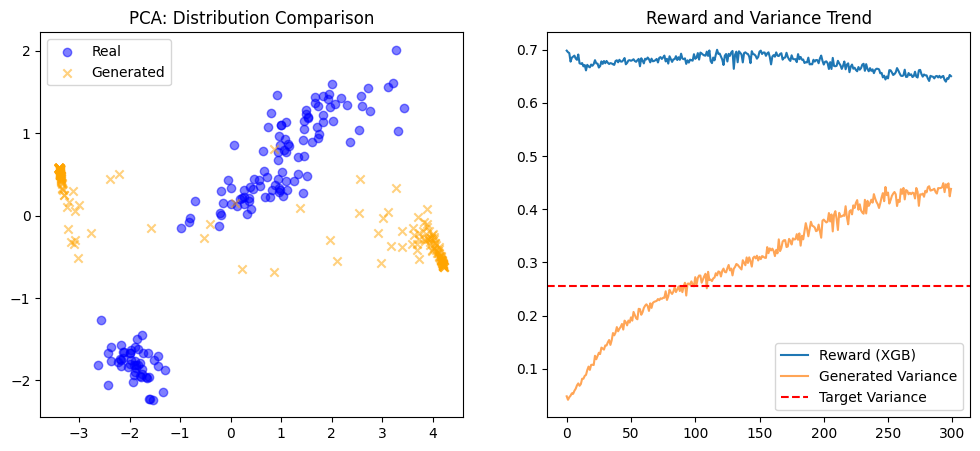

In [ ]:
# Data Setup
iris = load_iris()
scaler = MinMaxScaler()
real_data_raw = iris.data.astype(np.float32)
real_data_scaled = scaler.fit_transform(real_data_raw)
n_features = real_data_scaled.shape[1]
feature_names = iris.feature_names

# Get real stats to use as targets for the generator
target_mean = torch.tensor(real_data_scaled.mean(axis=0))
target_std = torch.tensor(real_data_scaled.std(axis=0))

def repelling_loss(fake_data):
    # Calculate pairwise distances
    dist = torch.cdist(fake_data, fake_data, p=2)
    # Exclude diagonal (distance to self is 0)
    mask = ~torch.eye(dist.size(0), dtype=torch.bool)
    dist = dist[mask].view(dist.size(0), -1)
    # Penalize small distances to prevent mode collapse
    return 1 / (dist.mean() + 1e-8)

# Generator
class UltimateGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(UltimateGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        # Add noise to input during training to increase variance
        if self.training:
            z = z + torch.randn_like(z) * 0.1
        return self.net(z)

# Discriminator (Weak XGBoost)
def train_weak_xgb(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    y = np.hstack([np.ones(len(real_samples)), np.zeros(len(fake_samples))])

    # Keep the discriminator weak (few trees, low depth) so it doesn't overpower the generator
    model = xgb.XGBClassifier(
        n_estimators=3,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        eval_metric='logloss'
    )
    model.fit(X, y)
    return model

# Training Loop
latent_dim = 24
batch_size = 64
gen = UltimateGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0003)

epochs = 300
history = {'loss': [], 'reward': [], 'diversity': []}

print("Starting training...")

for epoch in range(epochs):
    # A. Train Discriminator
    d_model = train_weak_xgb(gen, real_data_scaled, latent_dim, batch_size)

    # B. Train Generator
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # 1. Get raw rewards from XGBoost
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # 2. Reward Normalization (Z-score)
    # Forces the generator to keep improving even if samples are already scoring high
    if rewards.std() > 1e-4:
        norm_rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
    else:
        norm_rewards = rewards - 0.5 # Offset if rewards are identical

    # 3. Moment Matching Loss
    fake_mean = fake_data.mean(dim=0)
    fake_std = fake_data.std(dim=0)

    # Penalize deviations from target mean and std
    moment_loss = torch.mean((fake_mean - target_mean)**2) + torch.mean((fake_std - target_std)**2)

    # 4. Policy Gradient Loss
    log_probs = torch.log(fake_data + 1e-8)

    # Combine losses (moment matching heavily weighted to force distribution alignment)
    policy_loss = -torch.mean(norm_rewards * log_probs)
    total_loss = policy_loss + (10.0 * moment_loss) + (0.5 * repelling_loss(fake_data))

    total_loss.backward()
    optimizer.step()

    # Logging
    history['loss'].append(total_loss.item())
    history['reward'].append(rewards.mean().item())
    history['diversity'].append(fake_std.mean().item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Avg Reward: {rewards.mean().item():.3f} | Moment Loss: {moment_loss.item():.4f}")

#  Evaluation
gen.eval()
with torch.no_grad():
    final_z = torch.randn(200, latent_dim)
    fake_final_scaled = gen(final_z).numpy()
    fake_final = scaler.inverse_transform(fake_final_scaled)

df_real = pd.DataFrame(real_data_raw, columns=feature_names)
df_fake = pd.DataFrame(fake_final, columns=feature_names)

# Stats table
stats_real = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_fake = df_fake.describe().loc[['mean', 'std', 'min', 'max']]
comparison = pd.concat([stats_real, stats_fake], axis=0, keys=['REAL', 'GENERATED'])

print("\n" + "="*30 + " STATISTICS " + "="*30)
print(comparison)

# PCA Plot
pca = PCA(n_components=2)
all_pca = pca.fit_transform(np.vstack([real_data_raw, fake_final]))
real_pca = all_pca[:len(real_data_raw)]
fake_pca = all_pca[len(real_data_raw):]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Real', c='blue')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label='Generated', c='orange', marker='x')
plt.title("PCA: Distribution Comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], label='Reward (XGB)')
plt.plot(history['diversity'], label='Generated Variance', alpha=0.7)
plt.axhline(y=target_std.mean().item(), color='red', linestyle='--', label='Target Variance')
plt.title("Reward and Variance Trend")
plt.legend()
plt.show()

Improvements:


*   Maximum Mean Discrepancy, to match the distributions using as a base a guassian basis radial function kernel
*   Live mini-batch distribution sampling, match statistic against smallest batch indicators






Starting training with MMD and forced variance...
Epoch   0 | Avg Reward: 0.683 | MMD Loss: 0.0418
Epoch  50 | Avg Reward: 0.676 | MMD Loss: 0.0090
Epoch 100 | Avg Reward: 0.695 | MMD Loss: 0.0022
Epoch 150 | Avg Reward: 0.697 | MMD Loss: 0.0095
Epoch 200 | Avg Reward: 0.695 | MMD Loss: 0.0049
Epoch 250 | Avg Reward: 0.690 | MMD Loss: 0.0074

============================== STATISTICS ==============================
                sepal length (cm)  sepal width (cm)  petal length (cm)  \
REAL      mean           5.843333          3.057333           3.758000   
          std            0.828066          0.435866           1.765299   
          min            4.300000          2.000000           1.000000   
          max            7.900000          4.400000           6.900000   
GENERATED mean           5.935369          2.941918           3.868975   
          std            0.944391          0.766567           1.865490   
          min            4.379580          2.000349           1.

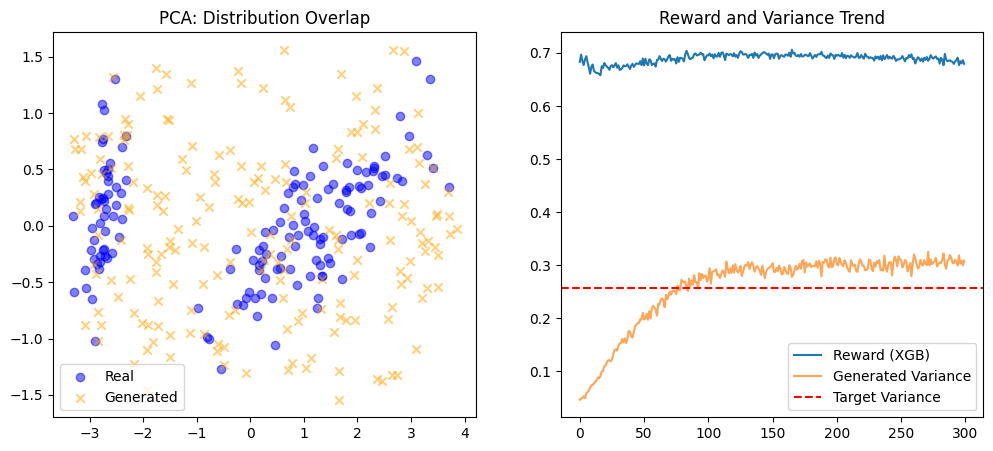

In [ ]:
#  Data Setup
iris = load_iris()
scaler = MinMaxScaler()
real_data_raw = iris.data.astype(np.float32)
real_data_scaled = scaler.fit_transform(real_data_raw)
n_features = real_data_scaled.shape[1]
feature_names = iris.feature_names

# Base stats for tracking
target_mean = torch.tensor(real_data_scaled.mean(axis=0))
target_std = torch.tensor(real_data_scaled.std(axis=0))

def compute_mmd(x, y, kernel='rbf'):
    """
    Compute Maximum Mean Discrepancy (MMD) between two batches.
    """
    def gaussian_kernel(x, y, sigma=1.0):
        beta = 1.0 / (2.0 * sigma**2)
        dist = torch.cdist(x, y)**2
        return torch.exp(-beta * dist)

    # Compute kernels for the MMD formula
    xx = gaussian_kernel(x, x) # Real-to-real
    yy = gaussian_kernel(y, y) # Fake-to-fake
    xy = gaussian_kernel(x, y) # Real-to-fake

    # MMD = mean(XX) + mean(YY) - 2*mean(XY)
    return torch.mean(xx) + torch.mean(yy) - 2.0 * torch.mean(xy)

def repelling_loss(fake_data):
    # Pairwise distances
    dist = torch.cdist(fake_data, fake_data, p=2)
    # Mask out the diagonal (distance to self is 0)
    mask = ~torch.eye(dist.size(0), dtype=torch.bool)
    dist = dist[mask].view(dist.size(0), -1)
    # Penalize small distances to spread out the generated samples
    return 1 / (dist.mean() + 1e-8)

# Generator
class UltimateGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(UltimateGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        # Inject noise during training to force variance
        if self.training:
            z = z + torch.randn_like(z) * 0.1
        return self.net(z)

#  Discriminator (Weak XGBoost)
def train_weak_xgb(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    y = np.hstack([np.ones(len(real_samples)), np.zeros(len(fake_samples))])

    # Intentionally myopic settings so it doesn't easily overpower the generator
    model = xgb.XGBClassifier(
        n_estimators=3,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        eval_metric='logloss'
    )
    model.fit(X, y)
    return model

# Training Loop
latent_dim = 24
batch_size = 64
gen = UltimateGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0003)

epochs = 300
history = {'loss': [], 'reward': [], 'diversity': []}

print("Starting training with MMD and forced variance...")

for epoch in range(epochs):
    # A. Train Discriminator
    d_model = train_weak_xgb(gen, real_data_scaled, latent_dim, batch_size)

    # B. Train Generator
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Grab a random batch of real data for MMD comparison
    idx = np.random.choice(len(real_data_scaled), batch_size, replace=False)
    real_batch = torch.tensor(real_data_scaled[idx], dtype=torch.float32)

    # 1. MMD Loss
    # Heavy weight to force distribution alignment
    dist_loss = compute_mmd(real_batch, fake_data)

    # 2. Reward and Policy Gradient
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)
    norm_rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    log_probs = torch.log(fake_data + 1e-8)
    policy_loss = -torch.mean(norm_rewards * log_probs)

    # Total loss breakdown
    total_loss = policy_loss + (20.0 * dist_loss) + (0.5 * repelling_loss(fake_data))

    total_loss.backward()
    optimizer.step()

    # Calculate current std for logging
    fake_std = fake_data.std(dim=0)

    # Logging
    history['loss'].append(total_loss.item())
    history['reward'].append(rewards.mean().item())
    history['diversity'].append(fake_std.mean().item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Avg Reward: {rewards.mean().item():.3f} | MMD Loss: {dist_loss.item():.4f}")

# Final Evaluation
gen.eval()
with torch.no_grad():
    final_z = torch.randn(200, latent_dim)
    fake_final_scaled = gen(final_z).numpy()
    fake_final = scaler.inverse_transform(fake_final_scaled)

df_real = pd.DataFrame(real_data_raw, columns=feature_names)
df_fake = pd.DataFrame(fake_final, columns=feature_names)

# Stats comparison
stats_real = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_fake = df_fake.describe().loc[['mean', 'std', 'min', 'max']]
comparison = pd.concat([stats_real, stats_fake], axis=0, keys=['REAL', 'GENERATED'])

print("\n" + "="*30 + " STATISTICS " + "="*30)
print(comparison)

# PCA Plot
pca = PCA(n_components=2)
all_pca = pca.fit_transform(np.vstack([real_data_raw, fake_final]))
real_pca = all_pca[:len(real_data_raw)]
fake_pca = all_pca[len(real_data_raw):]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Real', c='blue')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label='Generated', c='orange', marker='x')
plt.title("PCA: Distribution Overlap")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], label='Reward (XGB)')
plt.plot(history['diversity'], label='Generated Variance', alpha=0.7)
plt.axhline(y=target_std.mean().item(), color='red', linestyle='--', label='Target Variance')
plt.title("Reward and Variance Trend")
plt.legend()
plt.show()